# Prototypical Networks — Few-Shot Gesture Classification

Implements the **N-way K-shot Prototypical Network** from Snell et al. 2017,  
as covered in Stanford CS330 Lecture 6 (Non-Parametric Few-Shot Learning).

Architecture mirrors the existing `KerasMultiBranchClassifier` backbone —  
multi-branch 1D CNN + attention fusion — but **without a classification head**.  
Instead a projection to an L2-normalised embedding space is appended.  
Classification is done at inference time via nearest-prototype Euclidean distance.

**Key design choices**  
- No inner-loop gradient steps (unlike MAML) — just a forward pass per episode  
- Permutation-invariant prototype computation (mean over support embeddings)  
- Fixed Euclidean distance metric; the encoder learns the metric space  
- Gradient batching over `batch_episodes` episodes before each optimiser step  
- Early stopping on episodic validation accuracy


In [1]:
import os
import warnings
import logging
import tensorflow as tf

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["ABSL_LOG_LEVEL"] = "3"

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")
logging.getLogger("tensorflow").setLevel(logging.ERROR)

from __future__ import annotations

import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

import sys
sys.path.append('/kaggle/input/datasets/keithmarange/protostuffaha/')
sys.path.append('/kaggle/input/cmi-competition-code')

import data_utils
import utils_multitask_hardsharing as utils  # existing pipeline utils
import utils_proto                           # Prototypical Network utils


2026-05-30 01:58:13.918850: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780106294.187493      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780106294.271852      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780106294.910311      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780106294.910382      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780106294.910386      16 computation_placer.cc:177] computation placer alr

## Config

In [2]:
random_state    = 42
primary_target  = "gesture_action"

# Episode hyperparameters
N_WAY           = 4     # number of classes per episode (set to your gesture count)
K_SHOT          = 5     # support examples per class
N_QUERY         = 5     # query examples per class
EPISODES_PER_EPOCH = 200
META_EPOCHS     = 60
PATIENCE        = 10
LEARNING_RATE   = 5e-4
BATCH_EPISODES  = 4     # gradient accumulation over this many episodes

# Encoder
MAXLEN          = 160
EMBED_DIM       = 128
FUSION_MODE     = "attention"  # "attention" | "bigru" | "none"

# Train/val/test split
VAL_FRACTION    = 0.15
TEST_FRACTION   = 0.15

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
timestamp   = datetime.now().strftime("%Y%m%d_%H%M")


## Load data

In [3]:
data_root = data_utils.find_data_root()

raw_train_df   = pd.read_csv(data_root / "train.csv")
train_demo_df  = pd.read_csv(data_root / "train_demographics.csv")

print("raw_train_df :", raw_train_df.shape)
print("train_demo_df:", train_demo_df.shape)


Using Kaggle data folder: /kaggle/input/competitions/cmi-detect-behavior-with-sensor-data
raw_train_df : (574945, 341)
train_demo_df: (81, 8)


## Build labels DataFrame

In [4]:
# ============================================================
# Base dataframe + helper targets
# ============================================================

train_df = raw_train_df.set_index("row_id").copy(deep=True)

train_df.loc[:, "gesture_position"] = train_df["gesture"].str.split(" - ").str[0]
train_df.loc[:, "gesture_action"] = train_df["gesture"].str.split(" - ").str[-1]
train_df.loc[:, "is_target"] = train_df["sequence_type"].eq("Target").astype(int)
train_df.loc[:, "phase_target"] = train_df["phase"]
train_df.loc[:, "orientation_action"] = train_df["orientation"].astype(str) + "||" + train_df["gesture_action"].astype(str)

print("all sequences:", train_df["sequence_id"].nunique())
print("target sequences:", train_df.loc[train_df["sequence_type"].eq("Target"), "sequence_id"].nunique())
print("gesture_action classes:", sorted(train_df.loc[train_df["sequence_type"].eq("Target"), "gesture_action"].dropna().unique()))
print("orientation classes:", sorted(train_df.loc[train_df["sequence_type"].eq("Target"), "orientation"].dropna().unique()))
print("gesture_position classes:", sorted(train_df.loc[train_df["sequence_type"].eq("Target"), "gesture_position"].dropna().unique()))
print("full gesture classes:", sorted(train_df.loc[train_df["sequence_type"].eq("Target"), "gesture"].dropna().unique()))


all sequences: 8151
target sequences: 5113
gesture_action classes: ['pinch skin', 'pull hair', 'pull hairline', 'scratch']
orientation classes: ['Lie on Back', 'Lie on Side - Non Dominant', 'Seated Lean Non Dom - FACE DOWN', 'Seated Straight']
gesture_position classes: ['Above ear', 'Cheek', 'Eyebrow', 'Eyelash', 'Forehead', 'Neck']
full gesture classes: ['Above ear - pull hair', 'Cheek - pinch skin', 'Eyebrow - pull hair', 'Eyelash - pull hair', 'Forehead - pull hairline', 'Forehead - scratch', 'Neck - pinch skin', 'Neck - scratch']


## Subject-aware train / val / test split

Split at **subject level** so no subject leaks across folds.

In [5]:
# ============================================================
# Create label_df (one row per sequence with labels)
# ============================================================

# Create sequence-level metadata with labels
label_df = (
    train_df
    .drop_duplicates("sequence_id")
    [[
        "sequence_id", 
        "subject",           # Note: your column might be "subject" not "subject_id"
        "sequence_type",
        "gesture", 
        "gesture_action", 
        "gesture_position", 
        "orientation",
        "is_target"
    ]]
    .reset_index(drop=True)
    .copy()
)

# Rename if your column is "subject" (not "subject_id")
# If your column is actually "subject_id", change the column name above

print(f"label_df shape: {label_df.shape}")
print(f"Unique sequences: {label_df['sequence_id'].nunique()}")
print(f"Unique subjects: {label_df['subject'].nunique()}")

label_df shape: (8151, 8)
Unique sequences: 8151
Unique subjects: 81


In [6]:
# ============================================================
# Subject-based split
# ============================================================

TEST_FRACTION = 0.15   # 15% for test
VAL_FRACTION = 0.15    # 15% for validation

all_sequence_ids = label_df["sequence_id"].unique()

# Map sequence_id to subject (using the label_df)
seq_to_subject = dict(zip(label_df["sequence_id"], label_df["subject"]))

subjects = [seq_to_subject[sid] for sid in all_sequence_ids]

rng = np.random.default_rng(random_state)
unique_subjects = np.unique(subjects)
rng.shuffle(unique_subjects)

n_test = max(1, int(len(unique_subjects) * TEST_FRACTION))
n_val  = max(1, int(len(unique_subjects) * VAL_FRACTION))

test_subjects  = set(unique_subjects[:n_test])
val_subjects   = set(unique_subjects[n_test : n_test + n_val])
train_subjects = set(unique_subjects[n_test + n_val :])

# Get sequence IDs for each split
train_seq_ids = label_df[label_df["subject"].isin(train_subjects)]["sequence_id"].values
val_seq_ids   = label_df[label_df["subject"].isin(val_subjects)]["sequence_id"].values
test_seq_ids  = label_df[label_df["subject"].isin(test_subjects)]["sequence_id"].values

print(f"Train subjects: {len(train_subjects)}")
print(f"Val subjects: {len(val_subjects)}")
print(f"Test subjects: {len(test_subjects)}")
print(f"Train seqs: {len(train_seq_ids)}")
print(f"Val seqs: {len(val_seq_ids)}")
print(f"Test seqs: {len(test_seq_ids)}")

Train subjects: 57
Val subjects: 12
Test subjects: 12
Train seqs: 5704
Val seqs: 1223
Test seqs: 1224


## Feature extraction

Uses the same `SequenceExtractor` pipeline as the existing multi-task notebook.

In [7]:
pipe = Pipeline([
    ("sequence_builder", utils.AdvancedMultiDomainSequenceExtractor(
        acc_mode="raw",
        rotation_mode="quaternion",
        linear_acc_mode="baseline",
        use_acc_magnitude=True,
        tof_mode="pooled",
        thm_mode="centered",
        standardize="mean_std",
        # maxlen=MAXLEN,
        sequence_col="sequence_id",
    )),
])

# Fit on ALL training rows then transform each split
train_rows = raw_train_df[raw_train_df["sequence_id"].isin(train_seq_ids)]
val_rows   = raw_train_df[raw_train_df["sequence_id"].isin(val_seq_ids)]
test_rows  = raw_train_df[raw_train_df["sequence_id"].isin(test_seq_ids)]

pipe.fit(train_rows, label_df)

X_train_feat = pipe.transform(train_rows)
X_val_feat   = pipe.transform(val_rows)
X_test_feat  = pipe.transform(test_rows)

print("X_train_feat:", X_train_feat.shape, "| index=sequence_id")
print("X_val_feat  :", X_val_feat.shape)
print("X_test_feat :", X_test_feat.shape)


X_train_feat: (403044, 61) | index=sequence_id
X_val_feat  : (83034, 61)
X_test_feat : (88867, 61)


## Label DataFrames per split

In [8]:
y_train = label_df[label_df["sequence_id"].isin(train_seq_ids)].copy()
y_val   = label_df[label_df["sequence_id"].isin(val_seq_ids)].copy()
y_test  = label_df[label_df["sequence_id"].isin(test_seq_ids)].copy()

print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)


y_train: (5704, 8)
y_val  : (1223, 8)
y_test : (1224, 8)


## Build & meta-train the Prototypical Network

In [9]:
proto_clf = utils_proto.KerasPrototypicalClassifier(
    target=primary_target,
    maxlen=MAXLEN,
    padding_value=-999.0,

    # Encoder architecture (matches KerasMultiBranchClassifier defaults)
    branch_filters=       {"acc": "64-128", "rot": "32-64", "tof": "32", "thm": "16"},
    branch_kernel_sizes=  {"acc": "3-3",    "rot": "3-3",   "tof": "3",  "thm": "3"},
    branch_pool_sizes=    {"acc": "none-none", "rot": "none-none", "tof": "none", "thm": "none"},
    fusion_mode=FUSION_MODE,
    attention_heads=4,
    gru_units=128,
    use_batch_norm=True,
    spatial_dropout=0.1,
    embed_dim=EMBED_DIM,
    dropout=0.2,

    # Episode hyperparameters
    n_way=N_WAY,
    k_shot=K_SHOT,
    n_query=N_QUERY,
    episodes_per_epoch=EPISODES_PER_EPOCH,
    meta_epochs=META_EPOCHS,
    patience=PATIENCE,
    learning_rate=LEARNING_RATE,
    batch_episodes=BATCH_EPISODES,
    val_fraction=VAL_FRACTION,
    verbose=1,
    random_state=random_state,
)


In [10]:
proto_clf.fit(X_train_feat, y_train)
print(f"\nBest episodic val accuracy: {proto_clf.best_val_acc_:.4f}")


2026-05-30 02:01:48.418211: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch   1/60  train_loss=1.1705  train_acc=0.5263  val_loss=1.0699  val_acc=0.6210
Epoch   2/60  train_loss=0.9610  train_acc=0.6530  val_loss=0.9570  val_acc=0.6230
Epoch   3/60  train_loss=0.8786  train_acc=0.6938  val_loss=0.8720  val_acc=0.6850
Epoch   4/60  train_loss=0.8449  train_acc=0.7060  val_loss=0.8601  val_acc=0.6860
Epoch   5/60  train_loss=0.8025  train_acc=0.7105  val_loss=0.8619  val_acc=0.6500
Epoch   6/60  train_loss=0.7881  train_acc=0.7270  val_loss=0.7977  val_acc=0.7200
Epoch   7/60  train_loss=0.7863  train_acc=0.7270  val_loss=0.8058  val_acc=0.6750
Epoch   8/60  train_loss=0.7730  train_acc=0.7415  val_loss=0.7778  val_acc=0.7220
Epoch   9/60  train_loss=0.7529  train_acc=0.7547  val_loss=0.7854  val_acc=0.7280
Epoch  10/60  train_loss=0.7650  train_acc=0.7357  val_loss=0.7274  val_acc=0.7500
Epoch  11/60  train_loss=0.7189  train_acc=0.7702  val_loss=0.7321  val_acc=0.7530
Epoch  12/60  train_loss=0.7042  train_acc=0.7680  val_loss=0.6780  val_acc=0.8000
Epoc

## Training curves

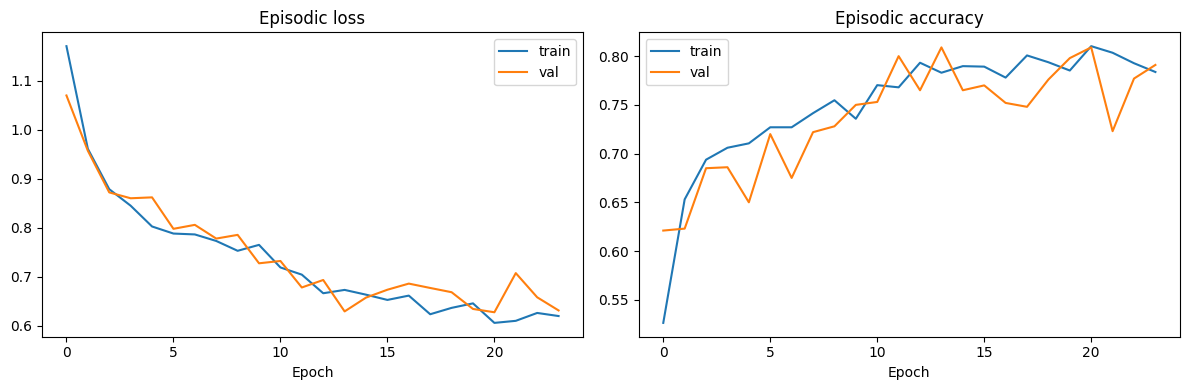

In [11]:
import matplotlib.pyplot as plt

hist = proto_clf.history_
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist["train_loss"], label="train")
axes[0].plot(hist["val_loss"],   label="val")
axes[0].set_title("Episodic loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(hist["train_acc"], label="train")
axes[1].plot(hist["val_acc"],   label="val")
axes[1].set_title("Episodic accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(results_dir / f"proto_training_curves_{timestamp}.png", dpi=120)
plt.show()


## Evaluation on held-out test set

**Prototypical inference** requires a support set.  
We use the **validation set** as the support set and the test set as queries.  
This mirrors the meta-test setup from CS330 Lecture 6:

```
compute prototypes from support set → classify queries by nearest prototype
```


In [12]:
# Build prototypes from validation support set
proto_clf.fit_support(X_val_feat, y_val)

# Predict on test queries
y_pred_test = proto_clf.predict(X_test_feat)

# Ground-truth labels (one per test sequence)
X_test_pad, test_seq_ids = proto_clf._pad(X_test_feat)
y_test_seq = proto_clf._collapse_y(test_seq_ids, y_test)

f1_macro = f1_score(y_test_seq, y_pred_test, average="macro")
print(f"Test macro-F1: {f1_macro:.4f}")
print()
print(classification_report(y_test_seq, y_pred_test))


Test macro-F1: 0.3413

                                            precision    recall  f1-score   support

                     Drink from bottle/cup       0.35      0.96      0.51        24
Feel around in tray and pull out an object       0.55      0.96      0.70        24
                            Glasses on/off       0.51      0.92      0.66        24
                       Pinch knee/leg skin       0.30      0.88      0.44        24
                 Pull air toward your face       0.41      0.10      0.16        72
                     Scratch knee/leg skin       0.17      0.04      0.07        24
                             Text on phone       0.82      0.55      0.66        96
                                Wave hello       0.38      0.86      0.52        72
                         Write name in air       0.42      0.14      0.21        72
                         Write name on leg       0.00      0.00      0.00        24
                                pinch skin       0.3

## K-shot ablation

One of the key benefits of Prototypical Networks is that you can vary K at inference time  
without retraining — the encoder is fixed; only the prototype computation changes.


In [13]:
from sklearn.model_selection import StratifiedShuffleSplit

le = proto_clf.le_
y_val_enc = le.transform(proto_clf._collapse_y(
    proto_clf._pad(X_val_feat)[1], y_val
))

X_val_pad, val_seq_ids = proto_clf._pad(X_val_feat)
val_embeddings = proto_clf.encoder_.predict(X_val_pad, verbose=0)

results_kshot = {}
for k in [1, 2, 5, 10, "all"]:
    if k == "all":
        sub_emb = val_embeddings
        sub_labels = y_val_enc
    else:
        rng_k = np.random.default_rng(42)
        sub_idx = []
        for cls in range(len(proto_clf.classes_)):
            cls_idx = np.flatnonzero(y_val_enc == cls)
            chosen = rng_k.choice(cls_idx, size=min(k, len(cls_idx)), replace=False)
            sub_idx.extend(chosen.tolist())
        sub_emb    = val_embeddings[sub_idx]
        sub_labels = y_val_enc[sub_idx]

    proto_clf.prototypes_ = proto_clf._compute_prototypes(sub_emb, sub_labels)

    y_pred_k = proto_clf.predict(X_test_feat)
    f1_k = f1_score(y_test_seq, y_pred_k, average="macro")
    results_kshot[k] = f1_k
    print(f"K={str(k):>4}  macro-F1 = {f1_k:.4f}")

# Restore full support
proto_clf.fit_support(X_val_feat, y_val)


K=   1  macro-F1 = 0.3132
K=   2  macro-F1 = 0.2523
K=   5  macro-F1 = 0.3191
K=  10  macro-F1 = 0.2981
K= all  macro-F1 = 0.3413


KerasPrototypicalClassifier(branch_filters={'acc': '64-128', 'rot': '32-64',
                                            'thm': '16', 'tof': '32'},
                            branch_kernel_sizes={'acc': '3-3', 'rot': '3-3',
                                                 'thm': '3', 'tof': '3'},
                            branch_pool_sizes={'acc': 'none-none',
                                               'rot': 'none-none',
                                               'thm': 'none', 'tof': 'none'},
                            learning_rate=0.0005, maxlen=160, meta_epochs=60)

## Embedding space visualisation (UMAP)

If `umap-learn` is not available this cell is skipped.

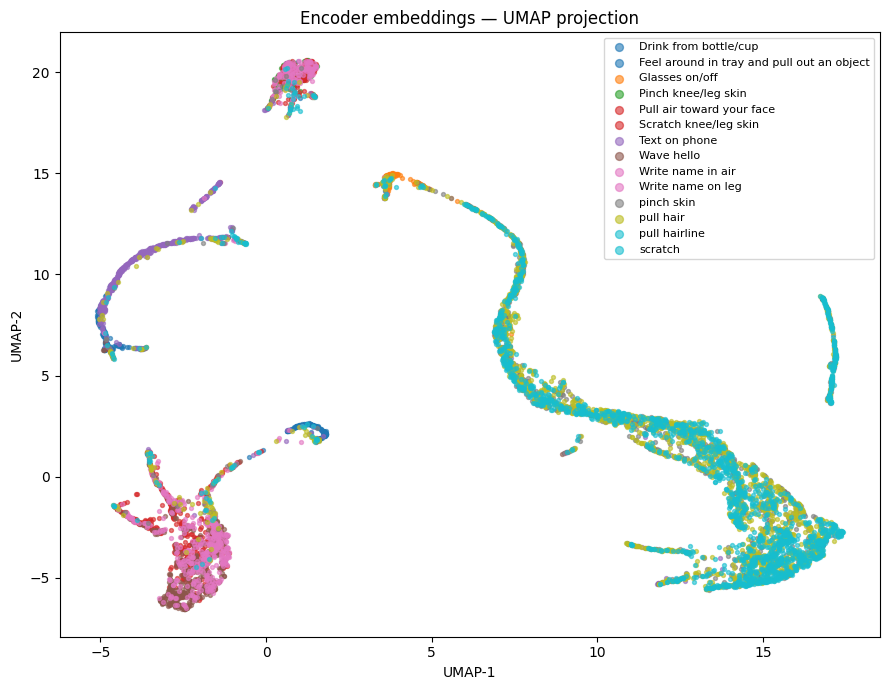

In [14]:
try:
    import umap

    X_all_pad, all_seq_ids = proto_clf._pad(
        pd.concat([X_train_feat, X_val_feat, X_test_feat])
    )
    all_emb = proto_clf.encoder_.predict(X_all_pad, verbose=0)

    all_y = pd.concat([
        proto_clf._collapse_y(proto_clf._pad(X_train_feat)[1], y_train),
        proto_clf._collapse_y(proto_clf._pad(X_val_feat)[1],   y_val),
        proto_clf._collapse_y(proto_clf._pad(X_test_feat)[1],  y_test),
    ]).reset_index(drop=True)

    reducer = umap.UMAP(n_components=2, random_state=random_state, n_neighbors=15)
    emb_2d  = reducer.fit_transform(all_emb)

    classes_unique = proto_clf.classes_
    cmap = plt.cm.get_cmap("tab10", len(classes_unique))

    fig, ax = plt.subplots(figsize=(9, 7))
    for i, cls in enumerate(classes_unique):
        mask = all_y == cls
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                   s=8, alpha=0.6, color=cmap(i), label=cls)
    ax.legend(markerscale=2, fontsize=8)
    ax.set_title("Encoder embeddings — UMAP projection")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    plt.tight_layout()
    plt.savefig(results_dir / f"proto_umap_{timestamp}.png", dpi=120)
    plt.show()

except ImportError:
    print("umap-learn not installed — skipping visualisation. pip install umap-learn")


## Save encoder weights

In [15]:
weights_path = results_dir / f"proto_encoder_{timestamp}.weights.h5"
proto_clf.encoder_.save_weights(str(weights_path))
print(f"Encoder weights saved to {weights_path}")

# Save label encoder classes for later inference
np.save(
    results_dir / f"proto_classes_{timestamp}.npy",
    proto_clf.classes_,
)
print("Label encoder classes saved.")


Encoder weights saved to results/proto_encoder_20260530_0158.weights.h5
Label encoder classes saved.
